<a href="https://colab.research.google.com/github/janepium/deteccion-anomalias-rt-iot/blob/main/notebooks/10_analisis_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Objetivo
2. Carga del dataset
3. Preparación de y_bin
4. Preparación de X
5. Train/Test
6. Random Forest inicial
7. Optimización con GridSearchCV
8. Random Forest optimizado
9. Comparación inicial vs optimizado
10. Feature Importance
11. Análisis de flow_duration
12. Random Forest sin flow_duration
13. Comparación con y sin flow_duration
14. Conclusiones

#Cargar el Dataset

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

df = pd.read_csv("dataset_limpio.csv", index_col=0)

print(df.shape)

(62338, 37)


#Crear y_bin
usando la misma definicion de edwin

In [3]:
NORMAL_CLASSES = {
    "MQTT_Publish",
    "Thing_Speak",
    "Wipro_bulb"
}

y_bin = (
    ~df["Attack_type"].isin(NORMAL_CLASSES)
).astype(int)

In [4]:
print(y_bin.value_counts())
print(y_bin.value_counts(normalize=True) * 100)

Attack_type
1    50323
0    12015
Name: count, dtype: int64
Attack_type
1    80.726042
0    19.273958
Name: proportion, dtype: float64


#Preparar X

In [5]:
LEAKY = [
    "id.orig_p",
    "id.resp_p",
    "proto",
    "service"
]

X = df.drop(
    columns=["Attack_type"]
)

X = X.drop(
    columns=LEAKY
)

#Train/Test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_bin,
    test_size=0.20,
    stratify=y_bin,
    random_state=42
)



#Random Forest inicial



In [7]:
rf_inicial = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [16]:
num_ejecuciones = 20
tiempos_entrenamiento = []

inicio_total = time.perf_counter()

for _ in range(num_ejecuciones):
    inicio = time.perf_counter()
    rf_inicial.fit(X_train, y_train)
    tiempos_entrenamiento.append(time.perf_counter() - inicio)

tiempo_total = time.perf_counter() - inicio_total
rf_inicial_train_time = sum(tiempos_entrenamiento) / num_ejecuciones

print(f"Tiempo promedio de entrenamiento ({num_ejecuciones} ejecuciones): {rf_inicial_train_time:.6f} segundos")
print(f"Tiempo total transcurrido: {tiempo_total:.2f} segundos")

Tiempo promedio de entrenamiento (20 ejecuciones): 2.666843 segundos
Tiempo total transcurrido: 53.34 segundos


In [24]:
num_ejecuciones = 20
tiempos_prediccion = []

for _ in range(num_ejecuciones):
    inicio = time.perf_counter()
    y_pred_inicial = rf_inicial.predict(X_test)
    tiempos_prediccion.append(time.perf_counter() - inicio)

# Tiempo promedio por ejecución
rf_inicial_predict_time = sum(tiempos_prediccion) / num_ejecuciones

print(
    f"Tiempo promedio de predicción ({num_ejecuciones} ejecuciones): {rf_inicial_predict_time:.6f} s")

Tiempo promedio de predicción (20 ejecuciones): 0.070842 s


In [28]:
y_prob_inicial = rf_inicial.predict_proba(X_test)[:, 1]

#Guardar las métricas del Random forest inicial

In [29]:
rf_inicial_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_inicial),
    "Precision": precision_score(
        y_test,
        y_pred_inicial,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_inicial,
        zero_division=0
    ),
    "F1-score": f1_score(
        y_test,
        y_pred_inicial,
        zero_division=0
    ),
    "F1-Macro": f1_score(
        y_test,
        y_pred_inicial,
        average="macro",
        zero_division=0
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob_inicial
    ),
    "Train time": rf_inicial_train_time,
    "Predict time": rf_inicial_predict_time
}

rf_inicial_metrics

{'Accuracy': 0.9975136349053577,
 'Precision': 0.9982125124131083,
 'Recall': 0.9987083954297069,
 'F1-score': 0.9984603923516265,
 'F1-Macro': 0.9960017021120766,
 'PR-AUC': np.float64(0.9999795658006277),
 'Train time': 2.6927872029499893,
 'Predict time': 0.07084211469996263}

# Crear la validación cruzada

In [31]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Optimización con GridSearchCV

In [33]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4],
    "max_features": ["sqrt", None],
}

rf_base = RandomForestClassifier(
    class_weight="balanced", random_state=42, n_jobs=-1
)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

inicio = time.perf_counter()
grid_rf.fit(X_train, y_train)
grid_time = time.perf_counter() - inicio

print("Tiempo total GridSearch:", round(grid_time, 2), "segundos")

Tiempo total GridSearch: 2643.59 segundos


#Mejores Hiperparámetros e Impacto

In [34]:
print("Mejores hiperparámetros encontrados:")
print(grid_rf.best_params_)

print("\nMejor F1-Macro obtenido en CV:", grid_rf.best_score_)

# Análisis de combinaciones de hiperparámetros
cv_results = pd.DataFrame(grid_rf.cv_results_)
top10_grid = cv_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "param_max_features",
        "mean_test_score",
        "std_test_score",
    ]
].sort_values("mean_test_score", ascending=False).head(10)

print("\n=== TOP 10 COMBINACIONES DEL GRIDSEARCH ===")
print(top10_grid)

Mejores hiperparámetros encontrados:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Mejor F1-Macro obtenido en CV: 0.9966755379737237

=== TOP 10 COMBINACIONES DEL GRIDSEARCH ===
    param_n_estimators param_max_depth  param_min_samples_split  \
0                  100            None                        2   
32                 100              25                        2   
33                 200              25                        2   
1                  200            None                        2   
16                 100              15                        2   
17                 200              15                        2   
9                  200            None                        2   
41                 200              25                        2   
25                 200              15                        2   
40                 100              25                        2   

    param_min_sam

#Random Forest Optimizado

In [35]:

rf_optimizado = grid_rf.best_estimator_

inicio = time.perf_counter()
y_pred_opt = rf_optimizado.predict(X_test)
rf_opt_predict_time = time.perf_counter() - inicio

y_prob_opt = rf_optimizado.predict_proba(X_test)[:, 1]

rf_opt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_opt),
    "Precision": precision_score(y_test, y_pred_opt, zero_division=0),
    "Recall": recall_score(y_test, y_pred_opt, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_opt, zero_division=0),
    "F1-Macro": f1_score(
        y_test, y_pred_opt, average="macro", zero_division=0
    ),
    "PR-AUC": average_precision_score(y_test, y_prob_opt),
    "Train time": grid_time,  # Búsqueda total
    "Predict time": rf_opt_predict_time,
}

#Comparación Inicial vs. Optimizado

In [36]:

comparacion = pd.DataFrame(
    [
        {"Modelo": "Random Forest Inicial", **rf_inicial_metrics},
        {"Modelo": "Random Forest Optimizado", **rf_opt_metrics},
    ]
)

print("=== TABLA COMPARATIVA: INICIAL VS OPTIMIZADO ===")
print(comparacion.to_string(index=False))

# Comparación de matriz de confusión (FN y FP)
tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_test, y_pred_inicial).ravel()
tn_o, fp_o, fn_o, tp_o = confusion_matrix(y_test, y_pred_opt).ravel()

print("\n=== ERRORES DE CLASIFICACIÓN ===")
print(f"RF Inicial   -> Falsos Negativos (FN): {fn_i} | Falsos Positivos (FP): {fp_i}")
print(f"RF Optimizado -> Falsos Negativos (FN): {fn_o} | Falsos Positivos (FP): {fp_o}")

=== TABLA COMPARATIVA: INICIAL VS OPTIMIZADO ===
                  Modelo  Accuracy  Precision   Recall  F1-score  F1-Macro  PR-AUC  Train time  Predict time
   Random Forest Inicial  0.997514   0.998213 0.998708   0.99846  0.996002 0.99998    2.692787      0.070842
Random Forest Optimizado  0.997514   0.998213 0.998708   0.99846  0.996002 0.99998 2643.592497      0.102726

=== ERRORES DE CLASIFICACIÓN ===
RF Inicial   -> Falsos Negativos (FN): 13 | Falsos Positivos (FP): 18
RF Optimizado -> Falsos Negativos (FN): 13 | Falsos Positivos (FP): 18


#Feature Importance y Análisis de flow_duration

Top 15 características más importantes:
flow_duration            0.198252
fwd_pkts_payload.avg     0.102805
bwd_pkts_payload.avg     0.101339
fwd_data_pkts_tot        0.092109
fwd_pkts_tot             0.078496
flow_pkts_per_sec        0.053210
bwd_pkts_tot             0.051543
fwd_subflow_bytes        0.040398
flow_ACK_flag_count      0.040262
flow_pkts_payload.min    0.024520
fwd_PSH_flag_count       0.021617
fwd_iat.std              0.021001
bwd_init_window_size     0.020473
bwd_pkts_payload.min     0.019722
flow_pkts_payload.tot    0.018571
dtype: float64


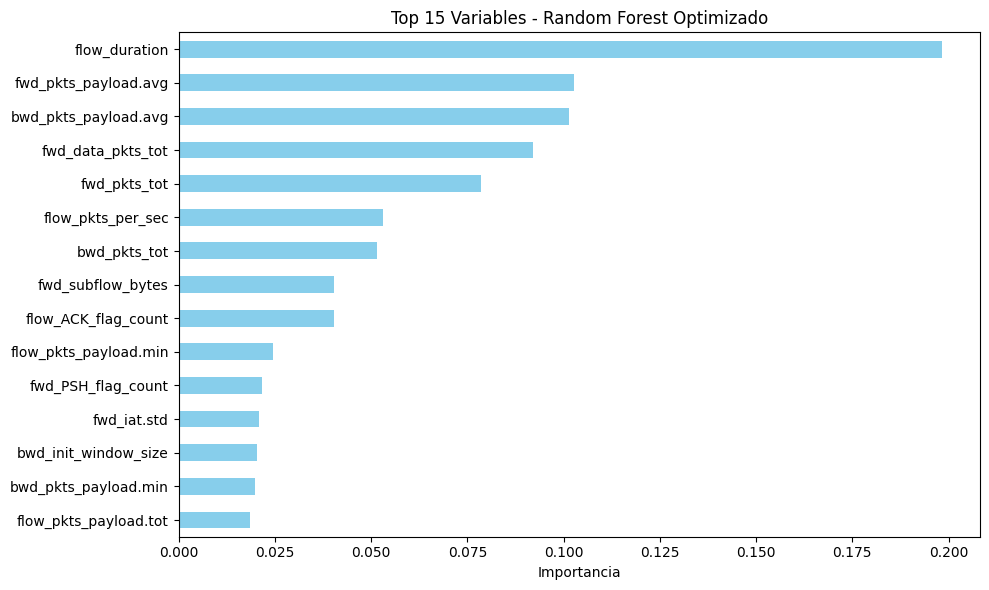


Importancia exacta de 'flow_duration': 0.198252 (19.83%)


In [37]:

importances = pd.Series(
    rf_optimizado.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print("Top 15 características más importantes:")
print(importances.head(15))

# Graficar la importancia de las primeras 15 variables
plt.figure(figsize=(10, 6))
importances.head(15).sort_values().plot(kind="barh", color="skyblue")
plt.title("Top 15 Variables - Random Forest Optimizado")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

flow_importance = importances.get("flow_duration", 0)
print(f"\nImportancia exacta de 'flow_duration': {flow_importance:.6f} ({flow_importance * 100:.2f}%)")

#Random Forest sin flow_duration

In [39]:

X_sin_duration = X.drop(columns=["flow_duration"])

# Split idéntico sin flow_duration
X_train_sd, X_test_sd, y_train_sd, y_test_sd = train_test_split(
    X_sin_duration, y_bin, test_size=0.20, stratify=y_bin, random_state=42
)

# Entrenar un nuevo modelo con los mejores hiperparámetros sin la variable
rf_sin_duration = RandomForestClassifier(
    **{
        **grid_rf.best_params_,
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
    }
)

inicio = time.perf_counter()
rf_sin_duration.fit(X_train_sd, y_train_sd)
tiempo_sd_train = time.perf_counter() - inicio

inicio = time.perf_counter()
y_pred_sd = rf_sin_duration.predict(X_test_sd)
tiempo_sd_predict = time.perf_counter() - inicio

y_prob_sd = rf_sin_duration.predict_proba(X_test_sd)[:, 1]

rf_sd_metrics = {
    "Accuracy": accuracy_score(y_test_sd, y_pred_sd),
    "Precision": precision_score(y_test_sd, y_pred_sd, zero_division=0),
    "Recall": recall_score(y_test_sd, y_pred_sd, zero_division=0),
    "F1-score": f1_score(y_test_sd, y_pred_sd, zero_division=0),
    "F1-Macro": f1_score(
        y_test_sd, y_pred_sd, average="macro", zero_division=0
    ),
    "PR-AUC": average_precision_score(y_test_sd, y_prob_sd),
    "Train time": tiempo_sd_train,
    "Predict time": tiempo_sd_predict,
}

#Comparación Final Completa y Conclusiones

In [40]:

tn_sd, fp_sd, fn_sd, tp_sd = confusion_matrix(y_test_sd, y_pred_sd).ravel()

tabla_final = pd.DataFrame(
    [
        {"Modelo": "RF Inicial", "FN": fn_i, "FP": fp_i, **rf_inicial_metrics},
        {"Modelo": "RF Optimizado", "FN": fn_o, "FP": fp_o, **rf_opt_metrics},
        {
            "Modelo": "RF Optimizado (sin flow_duration)",
            "FN": fn_sd,
            "FP": fp_sd,
            **rf_sd_metrics,
        },
    ]
)

print("=== TABLA RESUMEN GENERAL DE EXPERIMENTOS ===")
print(tabla_final.to_string(index=False))

=== TABLA RESUMEN GENERAL DE EXPERIMENTOS ===
                           Modelo  FN  FP  Accuracy  Precision   Recall  F1-score  F1-Macro   PR-AUC  Train time  Predict time
                       RF Inicial  13  18  0.997514   0.998213 0.998708   0.99846  0.996002 0.999980    2.692787      0.070842
                    RF Optimizado  13  18  0.997514   0.998213 0.998708   0.99846  0.996002 0.999980 2643.592497      0.102726
RF Optimizado (sin flow_duration)  10  18  0.997754   0.998213 0.999006   0.99861  0.996387 0.999867    2.179621      0.069146
